<div >
<img src = "figs/ans_banner_1920x200.png" />
</div>

# Caso-taller:  Recomendando Música

El objetivo de este caso-taller es construir un sistema de recomendación de Música utilizando los datos de [Last.fm](https://www.last.fm/) provistos  abiertamente por [grouplens](https://grouplens.org/about/what-is-grouplens/) para: **"avanzar la teoría y la práctica de la computación social mediante la construcción y la comprensión de sistemas *(de recomendación)* utilizados por personas reales".**

Los datos contienen información sobre artistas, usuarios, y las veces que estos escucharon sus canciones. Las bases se encuentran en los `Archivos de Laboratorio` en la carpeta `data`, allí también está disponible un archivo [README](data/readme.txt) que contiene más información sobre las bases.


## Instrucciones generales

1. Para desarrollar el *cuaderno*, primero debe descargarlo.

2. Para responder cada inciso deberá utilizar el espacio debidamente especificado.

3. La actividad será calificada sólo si sube el *cuaderno* de jupyter notebook con extensión `.ipynb` en la actividad designada como "entrega calificada por el personal".

4. El archivo entregado debe poder ser ejecutado localmente por el  tutor. Sea cuidadoso con la especificación de la ubicación de los archivos de soporte, guarde la carpeta de datos en el mismo `path` de su cuaderno, por ejemplo: `data`.

## Librerias

In [337]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse.linalg import svds
from apyori import apriori
from sklearn.metrics.pairwise import cosine_similarity
from scipy.linalg import svd

## Desarrollo


### 1. Carga de datos 

En la carpeta `data` se encuentran los archivos:

   - `artists.dat`  que contienen el identificador del artista (`id`), nombre (`name`), link a la página del artista en last.fm (`url`), y link a la imagen del usuario (`pictureURL`), vale aclarar que varios de estos links están rotos. 
   - `user_artists.dat`  que contiene identificador del usuario (`userID`), nombre del artista que escuchó (`artistID`), y las veces que los escuchó (`weight`).

Cargue estos datos en su *cuaderno*:

   1. Para la base de artistas seleccione las columnas de identificador de artista (`id`) y nombre (`name`). Renombre estas columnas para poder hacer la unión con la base `user_artists.dat`.
   2. Para la base de usuarios y artistas, renombre las columnas de forma tal que se mantenga la consistencia para unir con la base anterior, y renombre la columna `weight` a `nro_reproducciones`.
   3. Una estas bases.
   

In [30]:
artist = pd.read_csv("artists.dat",sep="\t+")
artist = artist.rename(columns={"id":"id_artist","name":"name_artist"})
artist.head()

C:\Users\danie\AppData\Local\Temp\ipykernel_4112\1708837368.py:1: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  artist = pd.read_csv("artists.dat",sep="\t+")


,id_artist,name_artist,url,pictureURL
0,1,MALICE MIZER,http://www.last.fm/music/MALICE+MIZER,http://userserve-ak.last.fm/serve/252/10808.jpg
1,2,Diary of Dreams,http://www.last.fm/music/Diary+of+Dreams,http://userserve-ak.last.fm/serve/252/3052066.jpg
2,3,Carpathian Forest,http://www.last.fm/music/Carpathian+Forest,http://userserve-ak.last.fm/serve/252/40222717...
3,4,Moi dix Mois,http://www.last.fm/music/Moi+dix+Mois,http://userserve-ak.last.fm/serve/252/54697835...
4,5,Bella Morte,http://www.last.fm/music/Bella+Morte,http://userserve-ak.last.fm/serve/252/14789013...


In [28]:
user_artist = pd.read_csv("user_artists.dat",sep="\t+")
user_artist = user_artist.rename(columns={"userID":"id_user","artistID":"id_artist","weight":"nro_reproducciones"})
user_artist

C:\Users\danie\AppData\Local\Temp\ipykernel_4112\2361273182.py:1: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  user_artist = pd.read_csv("user_artists.dat",sep="\t+")


,id_user,id_artist,nro_reproducciones
0,2,51,13883
1,2,52,11690
2,2,53,11351
3,2,54,10300
4,2,55,8983
...,...,...,...
92829,2100,18726,337
92830,2100,18727,297
92831,2100,18728,281
92832,2100,18729,280


In [32]:
df = pd.merge(user_artist, artist, on="id_artist",how="left")
df.head()

,id_user,id_artist,nro_reproducciones,name_artist,url,pictureURL
0,2,51,13883,Duran Duran,http://www.last.fm/music/Duran+Duran,http://userserve-ak.last.fm/serve/252/155668.jpg
1,2,52,11690,Morcheeba,http://www.last.fm/music/Morcheeba,http://userserve-ak.last.fm/serve/252/46005111...
2,2,53,11351,Air,http://www.last.fm/music/Air,http://userserve-ak.last.fm/serve/252/251119.jpg
3,2,54,10300,Hooverphonic,http://www.last.fm/music/Hooverphonic,http://userserve-ak.last.fm/serve/252/40553471...
4,2,55,8983,Kylie Minogue,http://www.last.fm/music/Kylie+Minogue,http://userserve-ak.last.fm/serve/252/12740835...


In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 92834 entries, 0 to 92833
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   id_user             92834 non-null  int64 
 1   id_artist           92834 non-null  int64 
 2   nro_reproducciones  92834 non-null  int64 
 3   name_artist         92834 non-null  object
 4   url                 92834 non-null  object
 5   pictureURL          92389 non-null  object
dtypes: int64(3), object(3)
memory usage: 5.0+ MB


### 2. Análisis preliminar. 

En esta sección exploraremos la base. Para ello responda las siguientes preguntas.

#### 2.1 ¿Cuantos usuarios y artistas hay en la base?


In [36]:
df['id_user'].nunique()

1892

In [38]:
df['id_artist'].nunique()

17632


#### 2.2 ¿Cuáles es la distribución de probabilidad del consumo por artista? (haga el calculo sin ponderar y ponderando por el numero de reproducciones) ¿Qué podemos inferir a partir de la comparación de ambas?

In [48]:
N = len(df['id_artist'])
N

92834

In [62]:
# frecuencia por artista
f_art = df["id_artist"].value_counts().sort_values(ascending=False)

In [64]:
f_art

89       611
289      522
288      484
227      480
300      473
        ... 
15496      1
15497      1
15498      1
15500      1
18730      1
Name: id_artist, Length: 17632, dtype: int64

In [66]:
# probabilidad de consumo sin ponderar
prob_sin_pon = f_art / N
prob_sin_pon

89       0.006582
289      0.005623
288      0.005214
227      0.005171
300      0.005095
           ...   
15496    0.000011
15497    0.000011
15498    0.000011
15500    0.000011
18730    0.000011
Name: id_artist, Length: 17632, dtype: float64

In [68]:
f_art_pon = df.groupby('id_artist')['nro_reproducciones'].sum().sort_values(ascending=False)
f_art_pon

id_artist
289      2393140
72       1301308
89       1291387
292      1058405
498       963449
          ...   
17468          1
14309          1
14308          1
17168          1
17170          1
Name: nro_reproducciones, Length: 17632, dtype: int64

In [70]:
# probabilidad de consumo con ponderar
prob_con_pon = f_art_pon / df['nro_reproducciones'].sum()
prob_con_pon

id_artist
289      3.459096e-02
72       1.880938e-02
89       1.866598e-02
292      1.529841e-02
498      1.392590e-02
             ...     
17468    1.445421e-08
14309    1.445421e-08
14308    1.445421e-08
17168    1.445421e-08
17170    1.445421e-08
Name: nro_reproducciones, Length: 17632, dtype: float64

#### 2.3 Para el usuario 8 (`userID==8`) ¿cuál es la distribución de reproducción de artistas basado en el número de reproducciones relativas?. Presente sus resultados usando tablas y/o gráficas. ¿Encuentra algún patrón en los artistas que escucha y las veces que reproduce? ¿Podemos decir algo de sus preferencias?


In [82]:
id_user_8 = df[df['id_user']==8]
id_user_8.head()

,id_user,id_artist,nro_reproducciones,name_artist,url,pictureURL
300,8,71,181,Dido,http://www.last.fm/music/Dido,http://userserve-ak.last.fm/serve/252/21564957...
301,8,89,921,Lady Gaga,http://www.last.fm/music/Lady+Gaga,http://userserve-ak.last.fm/serve/252/47390093...
302,8,97,354,Duffy,http://www.last.fm/music/Duffy,http://userserve-ak.last.fm/serve/252/55142075...
303,8,251,235,Whitney Houston,http://www.last.fm/music/Whitney+Houston,http://userserve-ak.last.fm/serve/252/58879935...
304,8,257,479,Mariah Carey,http://www.last.fm/music/Mariah+Carey,http://userserve-ak.last.fm/serve/252/4230813.jpg


In [84]:
id_user_8.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 50 entries, 300 to 349
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   id_user             50 non-null     int64 
 1   id_artist           50 non-null     int64 
 2   nro_reproducciones  50 non-null     int64 
 3   name_artist         50 non-null     object
 4   url                 50 non-null     object
 5   pictureURL          50 non-null     object
dtypes: int64(3), object(3)
memory usage: 2.7+ KB


In [104]:
id_user_8['nro_reproducciones'].describe()

count      50.000000
mean      725.580000
std       937.678834
min       173.000000
25%       347.750000
50%       486.500000
75%       775.500000
max      6291.000000
Name: nro_reproducciones, dtype: float64

In [106]:
tot_rep = id_user_8['nro_reproducciones'].sum()
print(f'El número total de reproducciones realizadas por el usuario con id 8 es: {tot_rep}')

El número total de reproducciones realizadas por el usuario con id 8 es: 36279


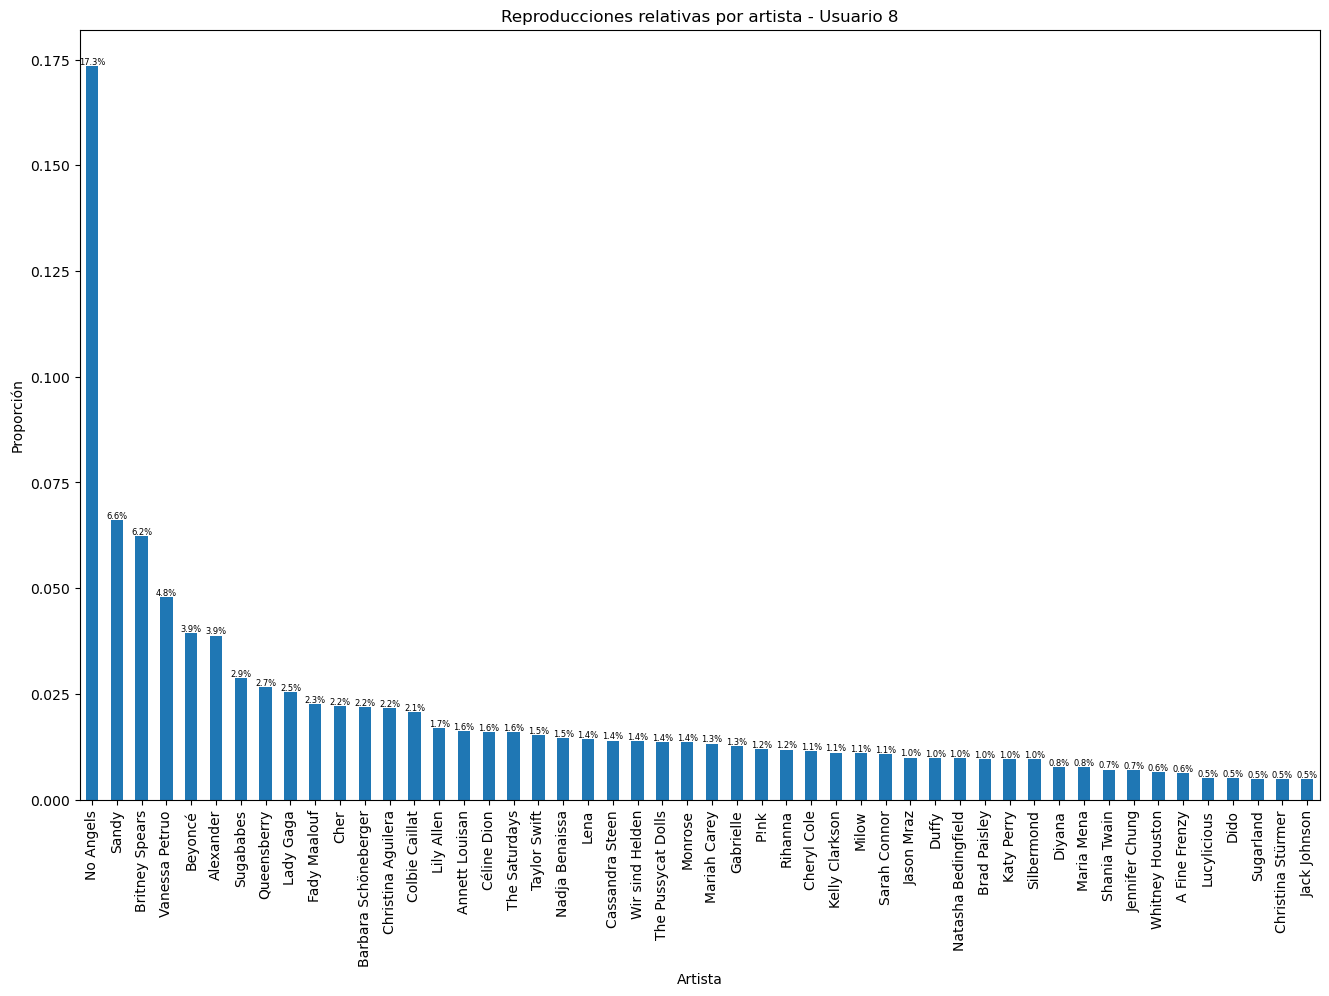

In [100]:
freq_8 = id_user_8.groupby("name_artist")["nro_reproducciones"].sum()
relativas = freq_8 / freq_8.sum()

# Graficar
ax = relativas.sort_values(ascending=False).plot(
    kind="bar",
    figsize=(16,10),
    title=f"Reproducciones relativas por artista - Usuario 8"
)

plt.ylabel("Proporción")
plt.xlabel("Artista")

for p in ax.patches:
    ax.annotate(f"{p.get_height()*100:.1f}%",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha="center", va="bottom",
               fontsize = 6)
    
plt.show()

In [128]:
qnt = id_user_8['nro_reproducciones'].quantile(0.90)

# Filtrar el 25% superior (valores mayores al percentil 75)
top25 = id_user_8[id_user_8['nro_reproducciones'] > qnt]

In [130]:
top25.sort_values('nro_reproducciones', ascending=False)

,id_user,id_artist,nro_reproducciones,name_artist,url,pictureURL
317,8,334,6291,No Angels,http://www.last.fm/music/No+Angels,http://userserve-ak.last.fm/serve/252/61126961...
318,8,335,2396,Sandy,http://www.last.fm/music/Sandy,http://userserve-ak.last.fm/serve/252/61835829...
307,8,289,2258,Britney Spears,http://www.last.fm/music/Britney+Spears,http://userserve-ak.last.fm/serve/252/60126439...
319,8,336,1735,Vanessa Petruo,http://www.last.fm/music/Vanessa+Petruo,http://userserve-ak.last.fm/serve/252/57670865...
310,8,295,1425,Beyoncé,http://www.last.fm/music/Beyonc%C3%A9,http://userserve-ak.last.fm/serve/252/61958009...


### 3. Generando Recomendaciones

En esta sección nos interesa generar recomendaciones ***nuevas y relevantes*** para el usuario 8 (`userID==8`). Para ello vamos a generar distintos sistemas de recomendación y comparar las recomendaciones generadas.

#### 3.1. Filtrado colaborativo sencillo: promedios simples.

Usando el promedio simple basado en el número de usuarios que escucha un artista (sin considerar el número de veces que estos usuarios reproducen al artista) genere una tabla y/o gráfica con 10 recomendaciones de artistas para este usuario. Explique con cuidado su procedimiento y justifique sus elecciones.

In [228]:
artistas_escuchados = id_user_8['id_artist'].unique()

user_x_art = df.groupby('id_artist')['id_user'].nunique().reset_index().sort_values(by='id_user',ascending=False)
user_x_art = user_x_art.rename(columns={"id_user": "usuarios_unicos"})

total_users = df['id_user'].nunique()

user_x_art['prom_user_x_art'] = user_x_art['usuarios_unicos'] / total_users

In [230]:
user_x_art

,id_artist,usuarios_unicos,prom_user_x_art
83,89,611,0.322939
283,289,522,0.275899
282,288,484,0.255814
221,227,480,0.253700
294,300,473,0.250000
...,...,...,...
9170,9403,1,0.000529
9173,9406,1,0.000529
9174,9407,1,0.000529
9175,9408,1,0.000529


In [240]:
user_x_art_filtrado = user_x_art[~user_x_art['id_artist'].isin(artistas_escuchados)]
user_x_art_filtrado = pd.merge(user_x_art_filtrado, artist[['id_artist', 'name_artist']], on='id_artist', how="left")
recomendados = user_x_art_filtrado[:10]
recomendados

,id_artist,usuarios_unicos,prom_user_x_art,name_artist
0,227,480,0.253700,The Beatles
1,67,429,0.226744,Madonna
2,333,417,0.220402,Avril Lavigne
3,190,400,0.211416,Muse
4,498,399,0.210888,Paramore
5,154,393,0.207717,Radiohead
6,65,369,0.195032,Coldplay
7,466,362,0.191332,Ke$ha
8,701,319,0.168605,Shakira
9,306,304,0.160677,Black Eyed Peas


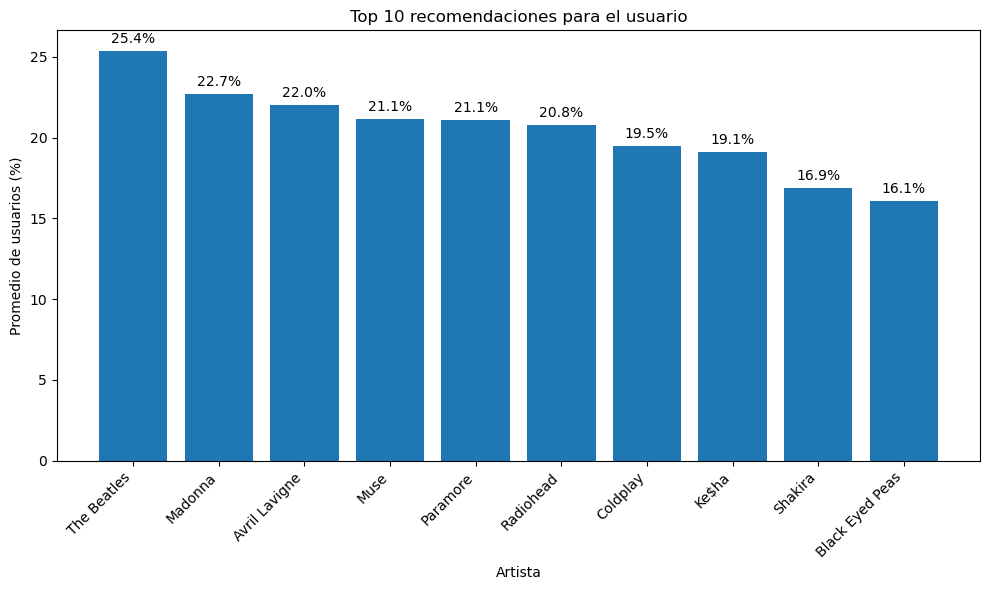

In [244]:
plt.figure(figsize=(10,6))
plt.bar(recomendados['name_artist'], recomendados['prom_user_x_art']*100)

plt.xlabel("Artista")
plt.ylabel("Promedio de usuarios (%)")
plt.title("Top 10 recomendaciones para el usuario")
plt.xticks(rotation=45, ha="right")

# mostrar porcentajes encima de cada barra
for i, v in enumerate(recomendados['prom_user_x_art']*100):
    plt.text(i, v + 0.5, f"{v:.1f}%", ha='center')

plt.tight_layout()
plt.show()

#### 3.2.  Filtrado colaborativo sencillo: promedios ponderados.

Utilice un promedio ponderado para generar las recomendaciones. Considere el número de veces que los usuarios reproducen al artista. En otras palabras, genere un ponderador que use el número de veces que el artista fue reproducido (`nro_reproducciones`). Este método pondera la popularidad de un artista, combinando el número de usuarios que lo escuchan con la frecuencia de reproducción, de manera que los artistas con más reproducciones reciban una mayor ponderación.

Genere una tabla y/o gráfica con las 10 principales recomendaciones de artistas para este usuario. Explique detalladamente su procedimiento y justifique sus elecciones. Compare estas recomendaciones con las del sistema implementado en el paso anterior.

In [272]:
reproducciones_totales = df.groupby('id_artist')['nro_reproducciones'].sum().reset_index()
reproducciones_totales = reproducciones_totales.rename(columns={'nro_reproducciones': 'total_reproducciones'})

user_x_art_ponderado = pd.merge(user_x_art, reproducciones_totales, on='id_artist', how='left')
user_x_art_ponderado['pop_ponderada'] = user_x_art_ponderado['usuarios_unicos'] * user_x_art_ponderado['total_reproducciones']
user_x_art_ponderado['pop_ponderada_perc'] = user_x_art_ponderado['pop_ponderada'] / user_x_art_ponderado['pop_ponderada'].sum()
user_x_art_ponderado_filtrado = user_x_art_ponderado[~user_x_art_ponderado['id_artist'].isin(artistas_escuchados)]


user_x_art_ponderado_filtrado = pd.merge(
    user_x_art_ponderado_filtrado,
    artist[['id_artist','name_artist']],
    on='id_artist',
    how='left'
)

recomendados_ponderados = user_x_art_ponderado_filtrado.sort_values('pop_ponderada', ascending=False).head(10)

In [274]:
recomendados_ponderados

,id_artist,usuarios_unicos,prom_user_x_art,total_reproducciones,pop_ponderada,pop_ponderada_perc,name_artist
1,67,429,0.226744,921198,395193942,0.038060,Madonna
4,498,399,0.210888,963449,384416151,0.037022,Paramore
13,72,282,0.149049,1301308,366968856,0.035342,Depeche Mode
0,227,480,0.253700,662116,317815680,0.030608,The Beatles
8,701,319,0.168605,688529,219640751,0.021153,Shakira
2,333,417,0.220402,525844,219276948,0.021118,Avril Lavigne
3,190,400,0.211416,485076,194030400,0.018687,Muse
5,154,393,0.207717,385306,151425258,0.014583,Radiohead
12,461,286,0.151163,489065,139872590,0.013471,Miley Cyrus
7,466,362,0.191332,384405,139154610,0.013402,Ke$ha


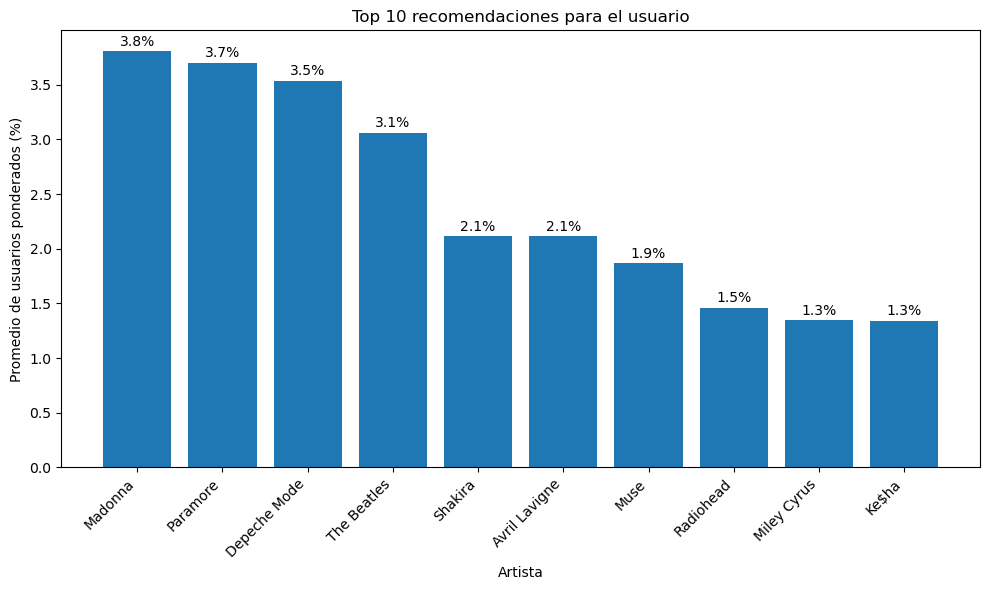

In [280]:
plt.figure(figsize=(10,6))
plt.bar(recomendados_ponderados['name_artist'], recomendados_ponderados['pop_ponderada_perc']*100)

plt.xlabel("Artista")
plt.ylabel("Promedio de usuarios ponderados (%)")
plt.title("Top 10 recomendaciones para el usuario")
plt.xticks(rotation=45, ha="right")

# mostrar porcentajes encima de cada barra
for i, v in enumerate(recomendados_ponderados['pop_ponderada_perc']*100):
    plt.text(i, v + 0.05, f"{v:.1f}%", ha='center')

plt.tight_layout()
plt.show()

(Utilice este espacio para describir el procedimiento, análisis y conclusiones).

#### 3.3.  Filtrado colaborativo sencillo: similitud de coseno.

Usando el promedio ponderado de reproducciones genere una tabla y/o gráfica  con 10 recomendaciones de artistas para este usuario. Para generar los pesos utilice la distancia de coseno. Explique con cuidado su procedimiento y justifique sus elecciones. Compare las recomendaciones con el sistema implementado en el paso anterior.

In [306]:
matriz = df.pivot_table(index='id_user', columns='id_artist', values='nro_reproducciones', fill_value=0)

In [307]:
matriz

id_artist,1,2,3,4,5,6,7,8,9,10,...,18736,18737,18738,18739,18740,18741,18742,18743,18744,18745
id_user,,,,,,,,,,,,,,,,,,,,,
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2095,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2096,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2097,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [312]:
usuario_objetivo = 8  
sim_coseno = cosine_similarity(matriz.loc[[usuario_objetivo]], matriz)[0]  
sim_df = pd.DataFrame({'id_user': matriz.index, 'similitud': sim_coseno})
sim_df.sort_values(by='similitud', ascending=False)

,id_user,similitud
6,8,1.000000
726,781,0.323876
254,271,0.323055
809,873,0.322389
317,339,0.321106
...,...,...
832,903,0.000000
830,899,0.000000
828,897,0.000000
827,896,0.000000


In [320]:
sim_vector = pd.Series(sim_df['similitud'].values, index=matriz.index)
matriz_ponderada = matriz.T.dot(sim_vector) / sim_vector.sum()

In [322]:
matriz_ponderada.sort_values(ascending=False)

id_artist
289      7267.275300
89       2494.204248
292      1991.823618
288      1681.802449
67       1380.550617
            ...     
11108       0.000000
11109       0.000000
11110       0.000000
11111       0.000000
9049        0.000000
Length: 17632, dtype: float64

In [324]:
matriz_ponderada = matriz_ponderada[~matriz_ponderada.index.isin(artistas_escuchados)]
matriz_ponderada.sort_values(ascending=False)

id_artist
67       1380.550617
55        842.955811
701       754.385774
461       748.711392
466       717.860074
            ...     
11108       0.000000
11109       0.000000
11110       0.000000
11111       0.000000
9074        0.000000
Length: 17582, dtype: float64

In [332]:
recomendados_coseno = matriz_ponderada.reset_index().rename(columns={0: 'score'})
recomendados_coseno = pd.merge(
    recomendados_coseno,
    artist[['id_artist','name_artist']],
    on='id_artist',
    how='left'
).sort_values(by='score',ascending=False)
recomendados_coseno = recomendados_coseno[:10]
recomendados_coseno

,id_artist,score,name_artist
61,67,1380.550617,Madonna
49,55,842.955811,Kylie Minogue
645,701,754.385774,Shakira
405,461,748.711392,Miley Cyrus
410,466,717.860074,Ke$ha
310,333,639.140771,Avril Lavigne
442,498,534.698430,Paramore
623,679,414.274802,Glee Cast
285,306,324.681675,Black Eyed Peas
302,325,310.129757,Ashley Tisdale


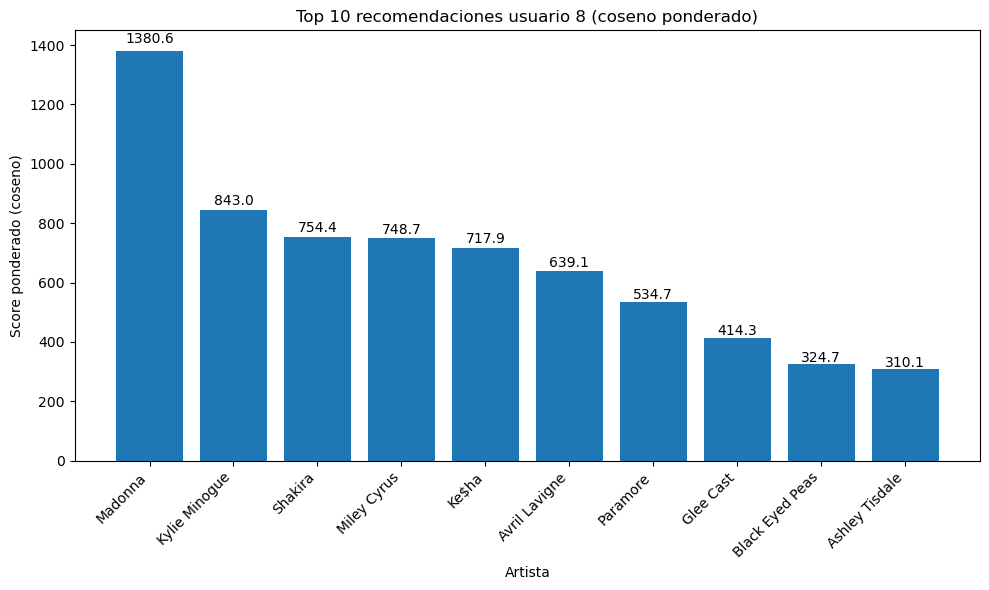

In [334]:
plt.figure(figsize=(10,6))
plt.bar(recomendados_coseno['name_artist'], recomendados_coseno['score'])
plt.xlabel("Artista")
plt.ylabel("Score ponderado (coseno)")
plt.title(f"Top 10 recomendaciones usuario {usuario_objetivo} (coseno ponderado)")
plt.xticks(rotation=45, ha="right")

# Etiquetas encima de cada barra
for i, v in enumerate(recomendados_coseno['score']):
    plt.text(i, v + v*0.02, f"{v:.1f}", ha='center')

plt.tight_layout()
plt.show()

(Utilice este espacio para describir el procedimiento, análisis y conclusiones).

#### 3.4.  Filtrado colaborativo usando SVD


Usando la descomposición en valores singulares (SVD) genere una tabla y/o gráfica  con 10 recomendaciones de artistas para este usuario.  Explique con cuidado su procedimiento y justifique sus elecciones. Compare las recomendaciones con el sistema implementado en los pasos anteriores.


In [339]:
matriz

id_artist,1,2,3,4,5,6,7,8,9,10,...,18736,18737,18738,18739,18740,18741,18742,18743,18744,18745
id_user,,,,,,,,,,,,,,,,,,,,,
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2095,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2096,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2097,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [346]:
R = matriz.values 
U, S, Vh = svd(R, full_matrices=False)

k = 10
U_k = U[:, :k]
S_k = np.diag(S[:k])
Vh_k = Vh[:k, :]

R_hat = np.dot(np.dot(U_k, S_k), Vh_k)
R_hat_df = pd.DataFrame(R_hat, index=matriz.index, columns=matriz.columns)

In [352]:
recomendaciones_usuario = R_hat_df.loc[usuario_objetivo]
recomendaciones_usuario = recomendaciones_usuario.drop(artistas_escuchados)

In [358]:
recomendaciones_svd = recomendaciones_usuario.reset_index().rename(columns={usuario_objetivo: 'score', 'id_artist':'id_artist'})
recomendaciones_svd = pd.merge(
    recomendaciones_svd,
    artist[['id_artist','name_artist']],
    on='id_artist',
    how='left'
).sort_values(by='score',ascending=False)

recomendaciones_svd =  recomendaciones_svd[:10]         
recomendaciones_svd

,id_artist,score,name_artist
405,461,381.493741,Miley Cyrus
61,67,308.760474,Madonna
645,701,226.743758,Shakira
410,466,157.393768,Ke$ha
49,55,155.527717,Kylie Minogue
310,333,111.116395,Avril Lavigne
296,318,77.843742,Hilary Duff
2478,2548,77.707786,Wanessa
623,679,76.389384,Glee Cast
148,157,71.137374,Michael Jackson


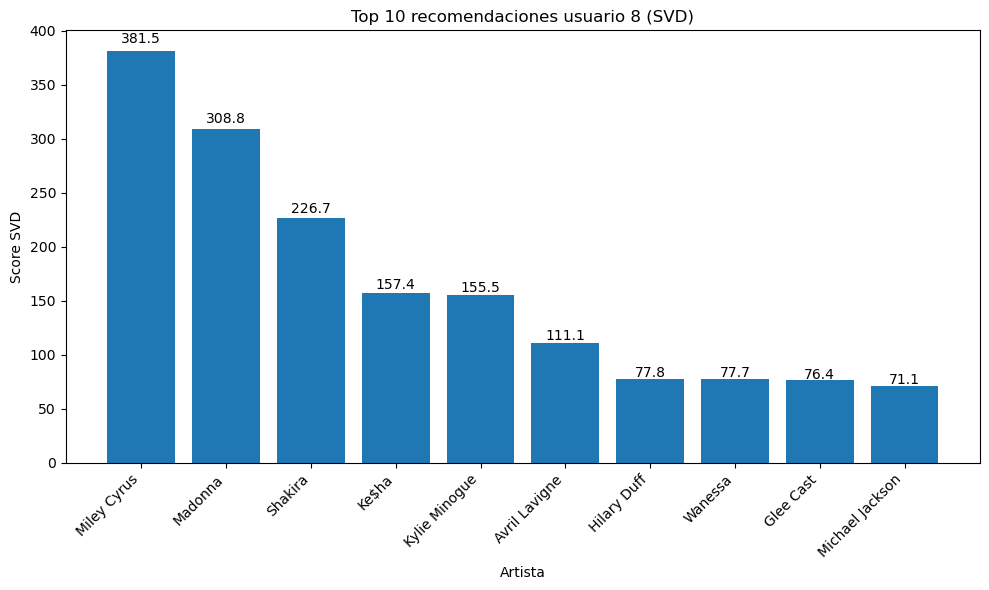

In [360]:
plt.figure(figsize=(10,6))
plt.bar(recomendaciones_svd['name_artist'], recomendaciones_svd['score'])
plt.xlabel("Artista")
plt.ylabel("Score SVD")
plt.title(f"Top 10 recomendaciones usuario {usuario_objetivo} (SVD)")
plt.xticks(rotation=45, ha="right")

for i, v in enumerate(recomendaciones_svd['score']):
    plt.text(i, v + v*0.02, f"{v:.1f}", ha='center')

plt.tight_layout()
plt.show()

(Utilice este espacio para describir el procedimiento, análisis y conclusiones).

#### 3.5.  Filtrado colaborativo usando Análisis de Canasta de Compra

Usando  el algoritmo `Apriori` genere una tabla y/o gráfica  con 10 recomendaciones de artistas para este usuario.  Explique con cuidado su procedimiento y justifique sus elecciones. Compare las recomendaciones con el sistema implementado en los pasos anteriores. Esto puede tomar mucho tiempo, sea cuidadoso al elegir los hiper-parámetors del modelo, utilice los resultados de las estadísticas descriptivas para elegir sus hiper-parámetros, y genere solo reglas con 2 elementos. (Puede también aprovechar los recursos de [Google Colab](https://colab.research.google.com/))


In [363]:
records = []
for i in df['id_user'].unique():
    records.append(list(df[df['id_user'] == i]['id_artist'].values))

In [441]:
association_rules = apriori(records, min_support=0.005, min_confidence=0.5, min_lift=3,max_length=2)
association_results = list(association_rules)

In [443]:
print("Derivamos {} reglas de asociación.".format(len(association_results)))

Derivamos 3220 reglas de asociación.


In [605]:
recomendaciones_usuario_8_apriori = pd.DataFrame(columns=['id_artist','support','confidence','lift'])
loc = 0

for rule in association_results:
    stat = rule.ordered_statistics[0]  # Primer OrderedStatistic
    antecedent = set(stat.items_base)
    consequent = next(iter(stat.items_add)) 
    support = rule.support
    confidence = stat.confidence
    lift = stat.lift
    
    if antecedent.issubset(artistas_escuchados):
        recomendaciones_usuario_8_apriori.loc[loc] = [consequent, support, confidence, lift]
        loc += 1
        
        print(f"Regla: {antecedent} -> {consequent}")
        print("Soporte:", support)
        print("Confianza:", confidence)
        print("Lift:", lift)
        print("=====================================")

Regla: {97} -> 55
Soporte: 0.021141649048625793
Confianza: 0.5
Lift: 3.174496644295302
Regla: {251} -> 55
Soporte: 0.015856236786469344
Confianza: 0.5882352941176471
Lift: 3.734701934465061
Regla: {257} -> 55
Soporte: 0.07188160676532769
Confianza: 0.5643153526970954
Lift: 3.582834386922498
Regla: {265} -> 55
Soporte: 0.028012684989429177
Confianza: 0.6463414634146342
Lift: 4.103617613357342
Regla: {296} -> 55
Soporte: 0.02748414376321353
Confianza: 0.6419753086419753
Lift: 4.075896926008783
Regla: {311} -> 55
Soporte: 0.026427061310782242
Confianza: 0.617283950617284
Lift: 3.91913165962383
Regla: {323} -> 55
Soporte: 0.0200845665961945
Confianza: 0.6333333333333333
Lift: 4.0210290827740485
Regla: {340} -> 55
Soporte: 0.01744186046511628
Confianza: 0.6
Lift: 3.8093959731543623
Regla: {349} -> 55
Soporte: 0.06712473572938689
Confianza: 0.5450643776824033
Lift: 3.460610075755393
Regla: {352} -> 55
Soporte: 0.04386892177589852
Confianza: 0.6484374999999999
Lift: 4.1169253355704685
Regla: 

In [607]:
recomendaciones_usuario_8_apriori.head()

,id_artist,support,confidence,lift
0,55.0,0.021142,0.500000,3.174497
1,55.0,0.015856,0.588235,3.734702
2,55.0,0.071882,0.564315,3.582834
3,55.0,0.028013,0.646341,4.103618
4,55.0,0.027484,0.641975,4.075897


In [609]:
recomendaciones_usuario_8_apriori = pd.merge(
    recomendaciones_usuario_8_apriori,
    artist[['id_artist','name_artist']],
    on='id_artist',
    how='left'
).sort_values(by='lift',ascending=False)
recomendaciones_usuario_8_apriori = recomendaciones_usuario_8_apriori.drop_duplicates(subset='name_artist')
recomendaciones_usuario_8_apriori = recomendaciones_usuario_8_apriori[:10]
recomendaciones_usuario_8_apriori

,id_artist,support,confidence,lift,name_artist
161,1459.0,0.005814,0.550000,13.692105,Carrie Underwood
109,296.0,0.015856,0.500000,11.679012,Sugababes
144,352.0,0.018499,0.583333,8.622396,Cheryl Cole
96,294.0,0.025899,0.604938,7.153395,Leona Lewis
72,291.0,0.034884,0.814815,5.929345,Kelly Clarkson
19,257.0,0.020085,0.745098,5.849483,Mariah Carey
107,299.0,0.023256,0.543210,4.917479,Jennifer Lopez
140,349.0,0.025899,0.604938,4.912203,The Pussycat Dolls
18,157.0,0.017970,0.666667,4.741855,Michael Jackson
149,344.0,0.022199,0.608696,4.662559,Taylor Swift


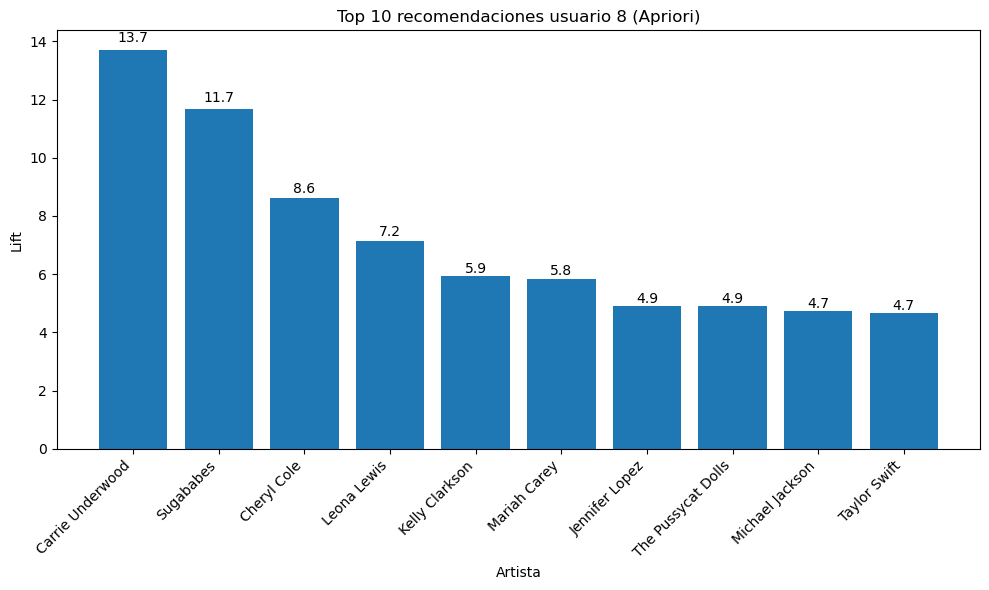

In [611]:
plt.figure(figsize=(10,6))
plt.bar(recomendaciones_usuario_8_apriori['name_artist'], recomendaciones_usuario_8_apriori['lift'])
plt.xlabel("Artista")
plt.ylabel("Lift")
plt.title(f"Top 10 recomendaciones usuario 8 (Apriori)")
plt.xticks(rotation=45, ha="right")

for i, v in enumerate(recomendaciones_usuario_8_apriori['lift']):
    plt.text(i, v + v*0.02, f"{v:.1f}", ha='center')

plt.tight_layout()
plt.show()

(Utilice este espacio para describir el procedimiento, análisis y conclusiones).

### 4. Recomendaciones generales 

De acuerdo con los resultados encontrados, en su opinión ¿qué procedimiento generó las mejores recomendaciones para este usuario? ¿Cómo implementaría una evaluación objetiva de estas recomendaciones? Justifique su respuesta.

(Utilice este espacio para describir el procedimiento, análisis y conclusiones).